# TFT Modelltraining — multivariat, mit Regressoren, log-transformiert (Basis für den Modellvergleich)

Trainiert **ein globales TFT-Modell** über mehrere Stationen gleichzeitig auf den um Ausreißer bereinigten Daten `../data/prepared_chronos/behandelt` aus 02_Datenaufbereitung_Beijing. Die Station **Aotizhongxin** wird im Training nicht verwendet aufgrund einer langen Datenlücke. Wir zeigen im Folgenden, dass die Anwendung auf die Daten dieser Station aufgrund des Trainings über viele Zeitreihen vergleichbarer Stationen dennoch eine Modellgüte erzielt, die vergleichbar zu den Stationen im Trainingsdatensatz ist. Mittels optuna wird eine Hyperparameteroptimierung durchgeführt und das finale Modell wird abgeschließend **gespeichert**, damit es im Notebook für den Algorithmenvergleich gegenüber  Seasonal Naive, Prophet und Chronos-2 geladen und ausgewertet werden kann, ohne neu trainieren zu müssen.

**Designentscheidungen:**

- **Trainingszeitraum:** nur Daten **vor dem 30.08.2016** fließen ins Training — der Rest (bis zum
  Datenende) bleibt für die Horizont-Auswertung reserviert. Das liegt bewusst direkt vor dem
  `ROLLING_START = 2016-09-01` aus dem separaten Rolling-Window-Vergleichsnotebook, damit sich derselbe
  Zeitraum später fair mit Seasonal Naive/Prophet/Chronos-2 vergleichen lässt.
- **Stationen:** zum Testen erstmal nur **3 Stationen** (`STATIONEN_TEST`, unten frei änderbar) statt aller
  11 (Aotizhongxin ausgeschlossen). Für den finalen Lauf wurden alle Stationen außer **Aotizhongxin** verwendet.
- **Log-Transformation** von `y` vor dem Training (PM2.5 ist rechtsschief) — Rücktransformation (`expm1`)
  vor jeder Fehlermaß-Berechnung.
- **Regressoren:**
  - `TEMP, DEWP, PRES, WSPM, RAIN, wd_sin, wd_cos` → **`futr_exog_list`** ("historisch UND zukünftig
    bekannt" — die tatsächlich gemessenen Werte dienen als Stellvertreter für eine echte
    Wettervorhersage, dasselbe Vorgehen wie im Chronos-2-Notebook). Bei Beschränkung auf Vorhersagen von maximal 3 Tagen darf eine angemessene Genauigkeit von Wetterprognosen angenommen werden. Für Zeiträume größer 3 Tage und der hohen Sensitivität der Algorithmen auf die exogenen Wettereinflüsse wird eine Anwendung auf längere Prognose-Zeiträume als nicht valide angesehen.
  - `SO2, NO2, CO, O3` → **`hist_exog_list`** (nur historisch — sie sind selbst Teil dessen, was
    prognostiziert werden soll, ihre Zukunftswerte "kennen" wäre Leakage).
- **Statischer Stations-Kovariat** (`stat_exog_list=['stationstyp']`): grobe Klassifikation
  Urban/Vorstadt je Station (Details + Warnhinweis unten) — numerisch kodiert, da `neuralforecast`
  **keine String-Spalten** in `static_df` akzeptiert (siehe Hinweis in der entsprechenden Zelle).
- **Explizite Standardisierung** der Wetter- und Schadstoff-Regressoren (`StandardScaler`, nur auf den
  Trainingsdaten gefittet) — TFTs eingebauter `scaler_type='robust'` normalisiert nur das **Ziel** `y`,
  nicht die exogenen Eingaben; `TEMP`/`PRES`/`WSPM` liegen aber auf sehr unterschiedlichen Skalen.
- **Quantil-Loss** (`MQLoss([0.1, 0.5, 0.9])`) statt reinem MAE — liefert zusätzlich ein 80 %-Intervall.
- **`fit()` + `save()`** statt `cross_validation()` für das Training: `cross_validation()` trainiert
  **immer ein komplett neues Modell**, auch nach einem vorherigen `fit()` (verifiziert) — für ein
  wiederverwendbares, gespeichertes Modell muss also explizit `fit()` aufgerufen werden, und die
  Horizont-Auswertung erfolgt danach über wiederholte `predict()`-Aufrufe auf genau diesem einen Modell.

## Bei TFT keine gelaggten Exogene im Gegensatz zu Prophet"

Beim Training und der Inferenz von TFT werden im Gegensatz zur folgenden Prophet Implementierung bewusst keine gelaggten Kovariaten eingesetz aus dem folgenden Grund: **Explizite Lag-Features** helfen vor allem Modellen **ohne** eingebautes Zeitgedächtnis (lineare Modelle, Gradient Boosting/XGBoost,
   Prophet-Regressoren). TFT hat mit LSTM-Encoder + Attention bereits ein eingebautes Zeitgedächtnis über
   das gesamte `input_size`-Fenster — explizite Lag-Spalten sind für TFT meist redundant und bringen kaum
   zusätzliches Signal, das das Modell ohnehin aus dem rohen historischen Fenster lernen kann.

**Ausblick:** Bei sehr kurzen Horizonten (z. B. 8h) kann eine explizite `y_lag1`/`y_lag24`-Spalte als
zusätzliches `hist_exog` in seltenen Fällen leicht helfen, weil sie dem Modell die "letzte bekannte
Steigung" direkt exponiert statt sie implizit lernen zu lassen. Bei einem echten Implementierungsprojekt würde es Sinn machen, die Verbesserung durch gelaggte Kovariaten auszuprobieren.

**Die folgenden Python-Umgebung wird empfohlen:**

> ⚙️ `pip install neuralforecast holidays scikit-learn`. Kernel mit GPU empfohlen
> (`accelerator='gpu'`); ohne GPU `accelerator='cpu'`.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, gc, shutil
import numpy as np
import pandas as pd
import torch
import holidays
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.losses.pytorch import MQLoss

torch.set_float32_matmul_precision('high')

# --- Pfade -------------------------------------------------------------------------------------------
DATA_DIR   = Path('../data/prepared_chronos/behandelt') # um starke Ausreißer und Datenlücken bereinigte Rohdaten
MODELL_DIR = Path('../models/tft_final_multivariat_v8')          # Ziel fuer nf.save()
ERGEBNIS_CSV = Path('../data/ergebnis_tft_final_v8.csv')

# --- Zeitraum / Horizonte -----------------------------------------------------------------------------
TRAIN_CUTOFF  = '2016-08-30'     # nur Daten VOR diesem Datum werden trainiert; alles danach = Auswertung
FREQ          = 'h'
HORIZONTE     = [8, 24, 48, 72]  # Einheitliche Prognosehorizonte für die Bewertung und spätere Modellvergleiche
H_TFT         = max(HORIZONTE)   # 72 -- Schrittweite der Walk-Forward-Auswertung unten

# --- Modell-Hyperparameter -----------------------------------------------------------------------------
# werden in optuna Optimierung zum Teil variiert
INPUT_SIZE    = 336 #336             # 2 Wochen Kontext (sichert den Wochenrhythmus im Encoder-Fenster)
MAX_STEPS     = 1000 #1000
BATCH_SIZE    = 32
HIDDEN_SIZE   = 128  # 128             # 128 besser als 64: mehrere Stationen + 7+4 exogene Variablen
                                  # gleichzeitig sind fuer hidden_size=64 eher knapp bemessen
DROPOUT       = 0.1              # bei Overfitting (Train-Loss sinkt viel schneller als Val-Loss) auf
                                  # 0.2-0.3 erhoehen
WINDOWS_BATCH = 64               # bei CUDA-Out-of-memory senken (64/32)
QUANTILES     = [0.1, 0.5, 0.9]
VAL_SIZE      = H_TFT * 3
VAL_CHECK_STEPS       = 5
EARLY_STOP_PATIENCE   = 20

# --- Regressoren ---------------------------------------------------------------------------------------
WETTER_REGRESSOREN         = ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos']
KALENDER_REGRESSOREN       = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'feiertag']
# ^ WICHTIG bei TFT (anders als beim vortrainierten Chronos-2!): TFT lernt komplett von Grund auf und
# kennt Tages-/Wochen-/Jahresmuster NICHT von selbst -- ohne diese expliziten Kalender-Features fehlt
# dem Modell ein wesentliches Signal, das Chronos-2 implizit aus seinem Pretraining mitbringt.
REGRESSOREN_ZUKUNFT       = WETTER_REGRESSOREN + KALENDER_REGRESSOREN   # historisch UND zukuenftig
REGRESSOREN_VERGANGENHEIT = ['SO2', 'NO2', 'CO', 'O3']                  # NUR historisch
REGRESSOREN_ZU_SKALIEREN  = WETTER_REGRESSOREN[:-2] + REGRESSOREN_VERGANGENHEIT
# ^ alles ausser wd_sin/wd_cos (bereits in [-1,1]) und den Kalender-Features (hour/day_sin/cos schon in
# [-1,1], feiertag ist 0/1) -- die brauchen keine Standardisierung

print('GPU verfuegbar:', torch.cuda.is_available())


GPU verfuegbar: True


## 1. Stationen: Auswahl, Ausschluss Aotizhongxin, Stationstyp (statischer Kovariat)

⚠️ **Zur Stationstyp-Klassifikation:** Es gibt keine offizielle Urban/Vorstadt-Einteilung im
PRSA-Datensatz selbst — die Zuordnung unten ist eine **grobe, manuelle Einschätzung** anhand der
allgemein bekannten Lage der Stadtbezirke (innerhalb der Ringstraßen vs. äußere/bergige Vororte). Für
belastbare Schlussfolgerungen aus dem `stationstyp`-Effekt bitte anhand einer verlässlicheren Quelle
(z. B. offizielle Stationsmetadaten des Beijing Municipal Environmental Monitoring Center) prüfen/verfeinern.


In [2]:
ALLE_STATIONEN = sorted(p.name.replace('chronos_', '').replace('.csv', '')
                       for p in DATA_DIR.glob('chronos_*.csv'))
ALLE_STATIONEN = [s for s in ALLE_STATIONEN if s != 'Aotizhongxin']   # Datenluecke -> ausgeschlossen
print(f'{len(ALLE_STATIONEN)} Stationen verfuegbar (ohne Aotizhongxin): {ALLE_STATIONEN}')

# --- zum Testen nur 3 Stationen -- fuer den finalen Lauf: STATIONEN_TEST = ALLE_STATIONEN -------------
STATIONEN_TEST = ALLE_STATIONEN# ['Changping', 'Dingling', 'Dongsi']
print(f'\nVerwendet fuer diesen Lauf ({len(STATIONEN_TEST)} Stationen): {STATIONEN_TEST}')

# --- grobe manuelle Stationstyp-Klassifikation (siehe Warnhinweis oben), numerisch kodiert -------------
# 0 = Urban (innerhalb/nahe der Ringstrassen), 1 = Vorstadt/Hintergrund (aeussere, eher bergige Lage)
STATIONSTYP_TEXT = {
    'Changping':      'Vorstadt/Hintergrund',
    'Dingling':       'Vorstadt/Hintergrund',
    'Dongsi':         'Urban',
    'Guanyuan':       'Urban',
    'Gucheng':        'Urban/Industrienah',
    'Huairou':        'Vorstadt/Hintergrund',
    'Nongzhanguan':   'Urban',
    'Shunyi':         'Vorstadt',
    'Tiantan':        'Urban/Park',
    'Wanliu':         'Urban',
    'Wanshouxigong':  'Urban',
}
STATIONSTYP_CODE = {
    'Urban': 0, 'Urban/Park': 0, 'Urban/Industrienah': 0,   # alle staedtischen Auspraegungen -> 0
    'Vorstadt/Hintergrund': 1, 'Vorstadt': 1,               # alle vorstaedtischen Auspraegungen -> 1
}

stat_df = pd.DataFrame({
    'unique_id': STATIONEN_TEST,
    'stationstyp': [float(STATIONSTYP_CODE[STATIONSTYP_TEXT[s]]) for s in STATIONEN_TEST],
})
print()
print(stat_df.to_string(index=False))


11 Stationen verfuegbar (ohne Aotizhongxin): ['Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

Verwendet fuer diesen Lauf (11 Stationen): ['Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

    unique_id  stationstyp
    Changping          1.0
     Dingling          1.0
       Dongsi          0.0
     Guanyuan          0.0
      Gucheng          0.0
      Huairou          1.0
 Nongzhanguan          0.0
       Shunyi          1.0
      Tiantan          0.0
       Wanliu          0.0
Wanshouxigong          0.0


## 2. Daten laden, regularisieren, log-transformieren, standardisieren

`y` (log-transformiert, fuer Training/Kontext) und `y_original` (echte µg/m³, nur fuer Auswertung/Plots)
bleiben beide im Frame -- neuralforecast nutzt ausschliesslich die Spalte `y` als Zielgroesse.


In [3]:
def lade_gesamt(station):
    df = pd.read_csv(DATA_DIR / f'chronos_{station}.csv', parse_dates=['ds'])
    return df.sort_values('ds').reset_index(drop=True)

def regularize(df, spalten):
    d = df.set_index('ds').sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq=FREQ))
    for c in spalten:
        d[c] = d[c].interpolate(limit_direction='both')
    d.index.name = 'ds'
    return d.reset_index()

# --- Kalender-Features: NACH regularize() berechnen (auf dem bereits lueckenfreien 'ds'), nicht vorher --
_CN_HOLIDAYS = holidays.country_holidays('CN', years=range(2013, 2018))

def add_feiertag(df):
    d = df.copy()
    d['feiertag'] = d['ds'].dt.date.astype('O').map(lambda t: 1 if t in _CN_HOLIDAYS else 0)
    return d

def add_time_features(df):
    d = df.copy()
    d['hour_sin'] = np.sin(2*np.pi*d['ds'].dt.hour/24); d['hour_cos'] = np.cos(2*np.pi*d['ds'].dt.hour/24)
    d['day_sin']  = np.sin(2*np.pi*d['ds'].dt.dayofyear/365.25); d['day_cos'] = np.cos(2*np.pi*d['ds'].dt.dayofyear/365.25)
    return d

def mae(y, yh):  return float(np.mean(np.abs(np.asarray(y,float)-np.asarray(yh,float))))
def rmse(y, yh): return float(np.sqrt(np.mean((np.asarray(y,float)-np.asarray(yh,float))**2)))
def mape(y, yh):
    y=np.asarray(y,float); yh=np.asarray(yh,float); m=y>0
    return float(np.mean(np.abs((y[m]-yh[m])/y[m]))*100) if m.any() else np.nan
def mase_skala(train_y, mp=24):
    a=np.asarray(train_y,float); return float(np.nanmean(np.abs(a[mp:]-a[:-mp])))

# alle_spalten hier bewusst nur die aus der CSV GELADENEN Regressoren (y + Wetter + Co-Schadstoffe) --
# die Kalender-Features (hour/day_sin/cos, feiertag) werden unten NACH regularize() berechnet, da sie
# rein aus 'ds' abgeleitet sind und daher nie Luecken/Interpolation brauchen.
alle_spalten = ['y'] + WETTER_REGRESSOREN + REGRESSOREN_VERGANGENHEIT

teile = []
skalen = {}          # MASE-Skala je Station, auf den ECHTEN (nicht log-transformierten) Trainings-y
letzte_ds = []
for st in STATIONEN_TEST:
    d = lade_gesamt(st)
    d = regularize(d, spalten=alle_spalten)
    d = add_time_features(d)
    d = add_feiertag(d)
    # WICHTIG: nur die tatsaechlich benoetigten Spalten behalten -- die Rohdaten enthalten weitere,
    # nicht-numerische Spalten (station, wd, ...) und Redundantes (year/month/day/hour). neuralforecast
    # versucht beim fit() ALLE Nicht-id/ds-Spalten in float zu konvertieren -- mit den Rohspalten drin
    # bricht das mit "could not convert string to float" ab.
    d = d[['ds'] + alle_spalten + KALENDER_REGRESSOREN].copy()
    d.insert(0, 'unique_id', st)

    train_maske = d['ds'] < pd.Timestamp(TRAIN_CUTOFF)
    skalen[st] = mase_skala(d.loc[train_maske, 'y'])
    letzte_ds.append(d['ds'].max())

    teile.append(d)

multi = pd.concat(teile, ignore_index=True)

# --- gemeinsamer Datenendpunkt ueber alle gewaehlten Stationen (fuer eine konsistente Walk-Forward-Auswertung) ---
DATENENDE = min(letzte_ds)
multi = multi[multi['ds'] <= DATENENDE].reset_index(drop=True)

print('Stationen:', STATIONEN_TEST)
print('Trainings-Cutoff:', TRAIN_CUTOFF)
print('Gemeinsames Datenende:', DATENENDE)
print(f'Zeilen gesamt: {len(multi)}  |  je Station: {len(multi) // len(STATIONEN_TEST)}')

# --- Log-Transformation (y_original bleibt fuer die Auswertung erhalten) -------------------------------
multi['y_original'] = multi['y']
multi['y'] = np.log1p(multi['y'])

# --- Standardisierung der Wetter-/Schadstoff-Regressoren, NUR auf den Trainingsdaten gefittet ----------
train_maske = multi['ds'] < pd.Timestamp(TRAIN_CUTOFF)
scaler = StandardScaler()
scaler.fit(multi.loc[train_maske, REGRESSOREN_ZU_SKALIEREN])
multi[REGRESSOREN_ZU_SKALIEREN] = scaler.transform(multi[REGRESSOREN_ZU_SKALIEREN])

print('\nSkalierte Regressoren:', REGRESSOREN_ZU_SKALIEREN)
print('MASE-Skalen je Station:', {k: round(v, 2) for k, v in skalen.items()})


Stationen: ['Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Trainings-Cutoff: 2016-08-30
Gemeinsames Datenende: 2017-02-28 23:00:00
Zeilen gesamt: 385704  |  je Station: 35064

Skalierte Regressoren: ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'SO2', 'NO2', 'CO', 'O3']
MASE-Skalen je Station: {'Changping': 51.41, 'Dingling': 51.17, 'Dongsi': 60.66, 'Guanyuan': 56.72, 'Gucheng': 56.97, 'Huairou': 50.17, 'Nongzhanguan': 60.82, 'Shunyi': 57.71, 'Tiantan': 57.42, 'Wanliu': 57.93, 'Wanshouxigong': 60.39}


## 3. TFT-Modell definieren, trainieren, speichern

`nf.fit()` trainiert **einmal** auf den Trainingsdaten (`ds < TRAIN_CUTOFF`); `nf.save()` schreibt das
Modell + Datensatz-Metadaten nach `MODELL_DIR`, damit es in einem anderen Notebook per
`NeuralForecast.load(path=...)` geladen werden kann, ohne neu zu trainieren.


In [4]:
from pytorch_lightning.callbacks import ModelCheckpoint

# --- finaler Long-Run mit den besten Parametern, volle Trainingsdaten, volles MAX_STEPS ----------------
train_df = multi[multi['ds'] < pd.Timestamp(TRAIN_CUTOFF)].reset_index(drop=True)
print(f'Trainingszeilen: {len(train_df)}  ({train_df["ds"].min()} bis {train_df["ds"].max()})')
#beste = study.best_params

beste = {
    'learning_rate': 0.0016738085788752138,
    'scaler_type': 'robust',
    'attn_dropout': 0.13682099526511077,
    'dropout': 0.14159046082342291,
    'n_head': 4
}
FIX_INPUT_SIZE = INPUT_SIZE
FIX_HIDDEN_SIZE  = 128     # wie gewuenscht fixiert
FIX_N_RNN_LAYERS = 1

# Checkpoint-Callback: merkt sich das beste Modell nach Val-Loss, statt nur den Endstand
CKPT_DIR_V2 = MODELL_DIR.parent / "checkpoints_tmp_v2"
shutil.rmtree(CKPT_DIR_V2, ignore_errors=True)
ckpt_cb = ModelCheckpoint(
    dirpath=str(CKPT_DIR_V2), filename="best",
    monitor='ptl/val_loss', mode='min', save_top_k=1,
)

model_v2 = TFT(
    h=H_TFT, input_size=FIX_INPUT_SIZE, stat_exog_list=['stationstyp'],
    hist_exog_list=REGRESSOREN_VERGANGENHEIT, futr_exog_list=REGRESSOREN_ZUKUNFT,
    loss=MQLoss(quantiles=QUANTILES), valid_loss=MQLoss(quantiles=QUANTILES),
    scaler_type='robust', dropout=beste['dropout'], attn_dropout=beste['attn_dropout'],
    n_head=beste['n_head'], n_rnn_layers=FIX_N_RNN_LAYERS, learning_rate=beste['learning_rate'],
    max_steps=MAX_STEPS, hidden_size=FIX_HIDDEN_SIZE,
    windows_batch_size=WINDOWS_BATCH, inference_windows_batch_size=WINDOWS_BATCH,
    val_check_steps=VAL_CHECK_STEPS, early_stop_patience_steps=EARLY_STOP_PATIENCE,
    accelerator=('gpu' if torch.cuda.is_available() else 'cpu'), devices=1,
    precision='16-mixed', enable_progress_bar=True,
    callbacks=[ckpt_cb],
    enable_checkpointing=True,          # <- NEU: sonst verwirft PL die ModelCheckpoint-Callback
)
nf_v2 = NeuralForecast(models=[model_v2], freq=FREQ)
nf_v2.fit(df=train_df, static_df=stat_df, val_size=VAL_SIZE)

# NEU: statt der Gewichte vom Trainingsende die Gewichte des besten Val-Loss-Checkpoints laden
if ckpt_cb.best_model_path:
    print(f'Bestes Checkpoint: {ckpt_cb.best_model_path}  (val_loss={ckpt_cb.best_model_score:.4f})')
    best_model = TFT.load_from_checkpoint(ckpt_cb.best_model_path)
    nf_v2.models[0] = best_model
else:
    print('Kein Checkpoint gefunden – es wird der Trainingsend-Stand gespeichert (kein Early Stop ausgelöst?).')

shutil.rmtree(MODELL_DIR, ignore_errors=True)
MODELL_DIR.parent.mkdir(parents=True, exist_ok=True)
nf_v2.save(path=str(MODELL_DIR), overwrite=True, save_dataset=True)
shutil.rmtree(CKPT_DIR_V2, ignore_errors=True)   # Zwischen-Checkpoints aufraeumen
print(f'Modell v2 gespeichert -> {MODELL_DIR}')

# Lernkurve + Vergleichsplot fuer das getunte Modell -- wiederverwendet die Funktionen von oben,
# einfach nf=nf_v2 mitgeben:

Seed set to 1


Trainingszeilen: 337392  (2013-03-01 00:00:00 bis 2016-08-29 23:00:00)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                    | Type                     | Params | Mode 
------------------------------------------------------------------------------
0  | loss                    | MQLoss                   | 3      | train
1  | valid_loss              | MQLoss                   | 3      | train
2  | hist_cat_embeddings     | ModuleList               | 0      | train
3  | futr_cat_embeddings     | ModuleList               | 0      | train
4  | stat_cat_embeddings     | ModuleList               | 0      | train
5  | padder_train            | ConstantPad1d            | 0      | train
6  | scaler                  | TemporalNorm             | 0      | train
7  | embedding               | TFTEmbedding             | 4.6 K  | train
8  | static_encoder          | StaticCovariateEncoder   | 381 K  | train
9  | temporal_encoder   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Kein Checkpoint gefunden – es wird der Trainingsend-Stand gespeichert (kein Early Stop ausgelöst?).
Modell v2 gespeichert -> ..\models\tft_final_multivariat_v8


### 3b. Lernkurve: Trainings- vs. Validierungs-Loss

⚠️ **`nf.models[0].trainer` NICHT fuer die Step-Anzahl verwenden** -- jeder `predict()`-Aufruf (auch alle
in der Walk-Forward-Schleife unten und in `vergleiche_tft()`) erzeugt intern einen neuen, temporaeren
Lightning-`Trainer` NUR fuer die Inferenz und ueberschreibt `model.trainer` damit. Nach mehreren
`predict()`-Aufrufen zeigt `.trainer.global_step` deshalb `0`, unabhaengig davon, wie lange trainiert
wurde -- das ist kein Trainingsproblem, sondern ein irrefuehrender Blick auf das falsche Attribut.

`train_trajectories`/`valid_trajectories` sitzen dagegen direkt auf dem Modell (nicht auf dem Trainer) und
werden von `predict()` nicht angefasst -- damit laesst sich die echte Lernkurve jederzeit nachtraeglich
plotten, auch nach der Walk-Forward-Auswertung weiter unten.


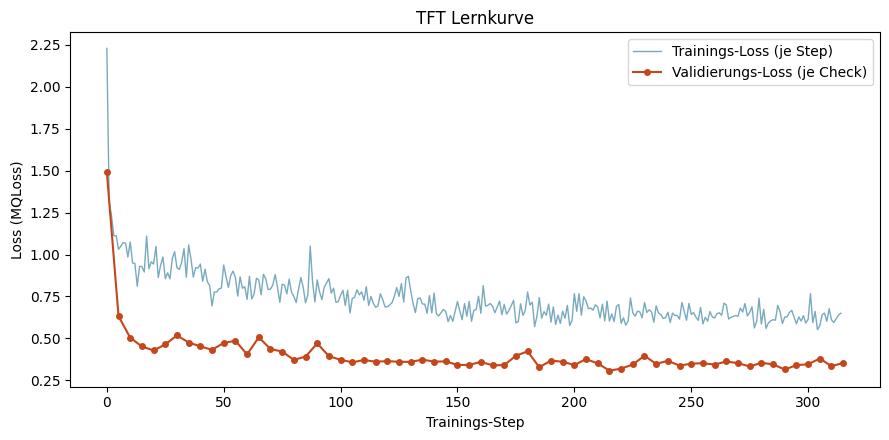

Tatsaechlich trainierte Steps: 314 von MAX_STEPS=1000 -> Early Stopping hat gegriffen!
Letzter Trainings-Loss:      0.6499
Letzter Validierungs-Loss:   0.3534
Hinweis: bester Validierungs-Loss war 0.3080 bei Step 215 -- danach evtl. leichtes Overfitting, oder Early Stopping haette (mit kleinerer patience) frueher greifen koennen.


In [5]:
def plotte_lernkurve(model=None):
    '''Plottet Trainings- vs. Validierungs-Loss ueber die Trainings-Steps. Zeigt ausserdem, wie viele
    Steps TATSAECHLICH trainiert wurden (nuetzlich um zu pruefen, ob Early Stopping vorzeitig gegriffen
    hat) -- zuverlaessiger als nf.models[0].trainer (siehe Warnhinweis oben).'''
    model = model or nf_v2.models[0]
    if not model.train_trajectories:
        print('Keine Trainings-Loss-Historie vorhanden (model.train_trajectories ist leer). Das kann an '
             'einer Versionskombination von lightning/pytorch-lightning liegen, bei der das interne '
             'Logging beim Testen dieses Notebooks nicht zuverlaessig funktionierte -- ist kein Zeichen '
             'dafuer, dass das Training selbst fehlgeschlagen ist. Kein Loss-Plot moeglich, aber Training/'
             'Speichern/Vorhersage funktionieren unabhaengig davon (siehe Horizont-Tabelle/vergleiche_tft).')
        return
    train_steps, train_losses = zip(*model.train_trajectories)
    valid_steps, valid_losses = zip(*model.valid_trajectories)
    if not valid_steps:
        print(f'Trainings-Loss vorhanden ({len(train_steps)} Steps), aber keine Validierungs-Checks '
             'geloggt (val_size zu klein fuer die gewaehlten Einstellungen?). Zeige nur Trainings-Loss.')
        plt.figure(figsize=(9, 4.5))
        plt.plot(train_steps, train_losses, color='#1C7293', alpha=0.6, lw=1, label='Trainings-Loss (je Step)')
        plt.xlabel('Trainings-Step'); plt.ylabel('Loss (MQLoss)'); plt.title('TFT Lernkurve (nur Training)')
        plt.legend(loc='best'); plt.tight_layout(); plt.show()
        return

    plt.figure(figsize=(9, 4.5))
    plt.plot(train_steps, train_losses, color='#1C7293', alpha=0.6, lw=1, label='Trainings-Loss (je Step)')
    plt.plot(valid_steps, valid_losses, color='#C4471C', marker='o', ms=4, lw=1.5, label='Validierungs-Loss (je Check)')
    plt.xlabel('Trainings-Step'); plt.ylabel('Loss (MQLoss)')
    plt.title('TFT Lernkurve')
    plt.legend(loc='best'); plt.tight_layout(); plt.show()

    print(f'Tatsaechlich trainierte Steps: {train_steps[-1]} von MAX_STEPS={MAX_STEPS}'
         + (' -> Early Stopping hat gegriffen!' if train_steps[-1] < MAX_STEPS - 1 else ' -> volle Laenge durchgelaufen.'))
    print(f'Letzter Trainings-Loss:      {train_losses[-1]:.4f}')
    print(f'Letzter Validierungs-Loss:   {valid_losses[-1]:.4f}')
    if valid_losses[-1] > min(valid_losses):
        print(f'Hinweis: bester Validierungs-Loss war {min(valid_losses):.4f} bei Step '
             f'{valid_steps[valid_losses.index(min(valid_losses))]} -- danach evtl. leichtes Overfitting, '
             f'oder Early Stopping haette (mit kleinerer patience) frueher greifen koennen.')

plotte_lernkurve()


## 6. Hyperparameter-Optimierung mit Optuna + finaler Long-Run (Modell `_v2`)

Kurze Trials mit **wenigen Steps** (`OPTUNA_MAX_STEPS`), danach **ein** langer Trainingslauf mit den besten
gefundenen Hyperparametern und vollem `MAX_STEPS` -- gespeichert als eigenständiges Modell mit `_v2`-Suffix
(`MODELL_DIR` bleibt unangetastet, das ursprüngliche Modell von oben geht nicht verloren).

**Wichtig zur Zielgröße der Trials:** Nicht der interne `valid_loss`-Verlauf (`model.valid_trajectories`)
wird verwendet, sondern eine **direkte MAE-Messung** auf einem kleinen, aus den Trainingsdaten
herausgeschnittenen Mini-Validierungsfenster (letzte `H_TFT` Stunden vor `TRAIN_CUTOFF`). Grund: das interne
Trajectory-Logging hat sich beim Testen in bestimmten `lightning`/`pytorch-lightning`-Versionskombinationen
als zerbrechlich erwiesen (leere Listen trotz erfolgreichem Training, je nach installierter Version) --
eine direkte `predict()` + MAE-Messung ist unabhängig davon zuverlässig und obendrein leichter zu
interpretieren (echte µg/m³ statt einer abstrakten Loss-Zahl).

**Gesuchte Parameter** (siehe letzte Antwort für die Begründung je Parameter): `learning_rate`, `n_head`,
`hidden_size`, `n_rnn_layers`, `dropout`, `attn_dropout`, `input_size`.

> ⚙️ `pip install optuna` -- falls dabei eure `torch`/`lightning`-Version verändert wird (Dependency-
> Resolver zieht ggf. andere Versionen nach), unbedingt danach `torch.cuda.is_available()` und einen
> kurzen Testlauf prüfen (siehe Hinweis oben zur Versionsfragilität).


In [6]:
import optuna
import logging

# Optunas EIGENE Verbosity gedrosselt (kein Sinn, jede Optuna-interne Detailmeldung zu sehen) --
# der Fortschritt kommt unten stattdessen ueber einen eigenen Callback (optuna_fortschritt), der
# GENAU EINE Zeile pro abgeschlossenem Trial druckt, unabhaengig von dieser Einstellung.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Lightning-Logs JE TRIAL stummschalten (Modell-Zusammenfassungstabelle, "GPU available: ...",
# "Seed set to 1", "Trainer.fit stopped: ..."), damit NUR noch die eigene Fortschrittszeile pro Trial
# zu sehen ist. Auskommentieren, falls ihr die Detail-Logs doch sehen wollt.
logging.getLogger('lightning.pytorch').setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
logging.getLogger('lightning.fabric').setLevel(logging.ERROR)
logging.getLogger('lightning_fabric').setLevel(logging.ERROR)

OPTUNA_MAX_STEPS  = 150      # deutlich weniger als MAX_STEPS (1000) -- nur fuers schnelle Vorsondieren
OPTUNA_N_TRIALS   = 21
MODELL_DIR_V2     = Path(str(MODELL_DIR) + '_v6')

# --- fixe (nicht gesuchte) Hyperparameter -----------------------------------------------------------
# input_size und hidden_size sind die groessten Speichertreiber (Attention skaliert ~quadratisch mit
# input_size; hidden_size linear/mehr in praktisch jeder Schicht), n_rnn_layers ebenfalls spuerbar.
# Fest auf sichere/gewuenschte Werte gesetzt statt gesucht -- vermeidet den CUDA-OOM von vorhin
# (input_size=504 + hidden_size=64 + n_rnn_layers=2 + n_head=8 in Kombination war zu viel):
FIX_INPUT_SIZE   = 336   # kleinster Wert aus dem bisherigen Suchraum -- bei Bedarf spaeter vorsichtig
                          # auf 336 hochtesten, NACHDEM diese Kombination sauber durchlaeuft
FIX_HIDDEN_SIZE  = 128     # wie gewuenscht fixiert
FIX_N_RNN_LAYERS = 1      # 2 Schichten verdoppeln den LSTM-Speicherbedarf ungefaehr

# GPU-Speicher von vorherigen Zellen (urspruengliches Modell, evtl. nf_v2) freigeben, BEVOR die Trials
# starten -- "42 GiB allocated" auf einer 12-GB-GPU (wie im Fehlerbild) ist ein klares Zeichen fuer
# Restspeicher aus frueheren Zellen derselben Kernel-Session, nicht fuer einen einzelnen Trial an sich.
# Falls das nicht reicht: Kernel neu starten und ab der Konfigurationszelle neu durchlaufen, dann direkt
# zu dieser Zelle springen (ohne das urspruengliche Modell vorher zu trainieren).
gc.collect()
torch.cuda.empty_cache()

# --- kleines Mini-Validierungsfenster: letzte H_TFT Stunden VOR TRAIN_CUTOFF, fuer alle Optuna-Trials
# gleich -- getrennt vom `train_df` fuer den finalen Long-Run (der nutzt weiter unten die VOLLEN Daten) ---
opt_val_start   = pd.Timestamp(TRAIN_CUTOFF) - pd.Timedelta(hours=H_TFT)
opt_train_df    = multi[multi['ds'] < opt_val_start].reset_index(drop=True)
opt_val_fenster = multi[(multi['ds'] >= opt_val_start) & (multi['ds'] < pd.Timestamp(TRAIN_CUTOFF))]
opt_futr_df     = opt_val_fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
opt_echte       = opt_val_fenster[['unique_id', 'ds', 'y_original']].rename(columns={'y_original': 'y'})

print(f'Optuna-Trainingsdaten: bis {opt_val_start}  |  Mini-Validierung: {opt_val_start} bis {TRAIN_CUTOFF}')


def objective(trial):
    # NUR NOCH speicher-guenstige Parameter gesucht (siehe Tabelle in der Antwort) -- input_size,
    # hidden_size, n_rnn_layers sind oben fest gesetzt, nicht mehr Teil der Suche.
    lr            = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_head        = trial.suggest_categorical('n_head', [2, 4])
    dropout       = trial.suggest_float('dropout', 0.05, 0.3)
    attn_dropout  = trial.suggest_float('attn_dropout', 0.0, 0.3)

    model = TFT(
        h=H_TFT, input_size=FIX_INPUT_SIZE, stat_exog_list=['stationstyp'],
        hist_exog_list=REGRESSOREN_VERGANGENHEIT, futr_exog_list=REGRESSOREN_ZUKUNFT,
        loss=MQLoss(quantiles=QUANTILES), valid_loss=MQLoss(quantiles=QUANTILES),
        scaler_type='robust', dropout=dropout, attn_dropout=attn_dropout,
        n_head=n_head, n_rnn_layers=FIX_N_RNN_LAYERS, learning_rate=lr,
        max_steps=OPTUNA_MAX_STEPS, hidden_size=FIX_HIDDEN_SIZE,
        windows_batch_size=WINDOWS_BATCH, inference_windows_batch_size=WINDOWS_BATCH,
        early_stop_patience_steps=-1,     # bei so wenigen Steps lohnt Early Stopping nicht
        accelerator=('gpu' if torch.cuda.is_available() else 'cpu'), devices=1,
        precision='16-mixed', enable_progress_bar=False,
    )
    nf_trial = NeuralForecast(models=[model], freq=FREQ)
    nf_trial.fit(df=opt_train_df, static_df=stat_df)

    pred = nf_trial.predict(df=opt_train_df, static_df=stat_df, futr_df=opt_futr_df)
    pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)
    vergleich = opt_echte.merge(pred[['unique_id', 'ds', 'yhat']], on=['unique_id', 'ds'])
    val_mae = mae(vergleich['y'], vergleich['yhat'])

    del model, nf_trial; gc.collect(); torch.cuda.empty_cache()
    return val_mae


def optuna_fortschritt(study, trial):
    '''Callback -- druckt GENAU EINE Zeile pro abgeschlossenem Trial (das ist der Fortschritt, den man
    bei optuna.logging.set_verbosity(WARNING) sonst nicht mehr sieht).'''
    stern = ' <- neuer bester Wert!' if trial.number == study.best_trial.number else ''
    print(f'[Trial {trial.number + 1}/{OPTUNA_N_TRIALS}] MAE = {trial.value:.3f} '
         f'(bisher bester: {study.best_value:.3f}){stern}')


study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, callbacks=[optuna_fortschritt])

print(f'\nBester Validierungs-MAE: {study.best_value:.3f} \u00b5g/m\u00b3')
print('Beste Parameter:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

# alle Trials als Tabelle zum Nachvollziehen/Sortieren -- z.B. study.trials_dataframe().sort_values('value')
study.trials_dataframe()[['number', 'value', 'params_learning_rate', 'params_n_head',
                          'params_dropout', 'params_attn_dropout']].round(4)


Optuna-Trainingsdaten: bis 2016-08-27 00:00:00  |  Mini-Validierung: 2016-08-27 00:00:00 bis 2016-08-30
[Trial 1/21] MAE = 6.611 (bisher bester: 6.611) <- neuer bester Wert!
[Trial 2/21] MAE = 7.655 (bisher bester: 6.611)
[Trial 3/21] MAE = 7.958 (bisher bester: 6.611)
[Trial 4/21] MAE = 7.723 (bisher bester: 6.611)
[Trial 5/21] MAE = 6.101 (bisher bester: 6.101) <- neuer bester Wert!
[Trial 6/21] MAE = 5.022 (bisher bester: 5.022) <- neuer bester Wert!
[Trial 7/21] MAE = 7.507 (bisher bester: 5.022)
[Trial 8/21] MAE = 6.360 (bisher bester: 5.022)
[Trial 9/21] MAE = 7.756 (bisher bester: 5.022)
[Trial 10/21] MAE = 6.879 (bisher bester: 5.022)
[Trial 11/21] MAE = 8.660 (bisher bester: 5.022)
[Trial 12/21] MAE = 4.813 (bisher bester: 4.813) <- neuer bester Wert!
[Trial 13/21] MAE = 7.821 (bisher bester: 4.813)
[Trial 14/21] MAE = 5.620 (bisher bester: 4.813)
[Trial 15/21] MAE = 6.043 (bisher bester: 4.813)
[Trial 16/21] MAE = 7.052 (bisher bester: 4.813)
[Trial 17/21] MAE = 4.733 (bisher

,number,value,params_learning_rate,params_n_head,params_dropout,params_attn_dropout
0,0,6.6114,0.0006,2,0.1997,0.0468
1,1,7.6549,0.0002,4,0.2003,0.2124
2,2,7.9580,0.0001,2,0.1031,0.0545
3,3,7.7230,0.0002,4,0.1580,0.0874
4,4,6.1005,0.0017,4,0.1416,0.1368
5,5,5.0223,0.0037,4,0.1981,0.0139
6,6,7.5073,0.0016,2,0.2872,0.2897
7,7,6.3598,0.0041,2,0.2211,0.1320
8,8,7.7556,0.0002,2,0.2773,0.0776
9,9,6.8786,0.0021,4,0.1867,0.0555


In [7]:
from pytorch_lightning.callbacks import ModelCheckpoint

ckpt_cb = ModelCheckpoint(monitor='ptl/val_loss', mode='min', save_top_k=1)
# --- finaler Long-Run mit den besten Parametern, volle Trainingsdaten, volles MAX_STEPS ----------------
train_df = multi[multi['ds'] < pd.Timestamp(TRAIN_CUTOFF)].reset_index(drop=True)
print(f'Trainingszeilen: {len(train_df)}  ({train_df["ds"].min()} bis {train_df["ds"].max()})')
#beste = study.best_params


beste = {
    'learning_rate': 0.0016738085788752138,
    'scaler_type': 'robust',
    'attn_dropout': 0.13682099526511077,
    'dropout': 0.14159046082342291,
    'n_head': 4
}
FIX_INPUT_SIZE=INPUT_SIZE
FIX_HIDDEN_SIZE  = 128     # wie gewuenscht fixiert
FIX_N_RNN_LAYERS = 1
model_v2 = TFT(
    h=H_TFT, input_size=FIX_INPUT_SIZE, stat_exog_list=['stationstyp'],
    hist_exog_list=REGRESSOREN_VERGANGENHEIT, futr_exog_list=REGRESSOREN_ZUKUNFT,
    loss=MQLoss(quantiles=QUANTILES), valid_loss=MQLoss(quantiles=QUANTILES),
    scaler_type='robust', dropout=beste['dropout'], attn_dropout=beste['attn_dropout'],
    n_head=beste['n_head'], n_rnn_layers=FIX_N_RNN_LAYERS, learning_rate=beste['learning_rate'],
    max_steps=MAX_STEPS, hidden_size=FIX_HIDDEN_SIZE,                     # <- volles MAX_STEPS, nicht OPTUNA_MAX_STEPS
    windows_batch_size=WINDOWS_BATCH, inference_windows_batch_size=WINDOWS_BATCH,
    val_check_steps=VAL_CHECK_STEPS, early_stop_patience_steps=EARLY_STOP_PATIENCE,
    accelerator=('gpu' if torch.cuda.is_available() else 'cpu'), devices=1,
    precision='16-mixed', enable_progress_bar=True,
)
nf_v2 = NeuralForecast(models=[model_v2], freq=FREQ)
nf_v2.fit(df=train_df, static_df=stat_df, val_size=VAL_SIZE)

shutil.rmtree(MODELL_DIR_V2, ignore_errors=True)
MODELL_DIR_V2.parent.mkdir(parents=True, exist_ok=True)
nf_v2.save(path=str(MODELL_DIR_V2), overwrite=True, save_dataset=True)
print(f'Modell v2 gespeichert -> {MODELL_DIR_V2}')

# Lernkurve + Vergleichsplot fuer das getunte Modell -- wiederverwendet die Funktionen von oben,
# einfach nf=nf_v2 mitgeben:


Trainingszeilen: 337392  (2013-03-01 00:00:00 bis 2016-08-29 23:00:00)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Modell v2 gespeichert -> ..\models\tft_final_multivariat_v8_v6


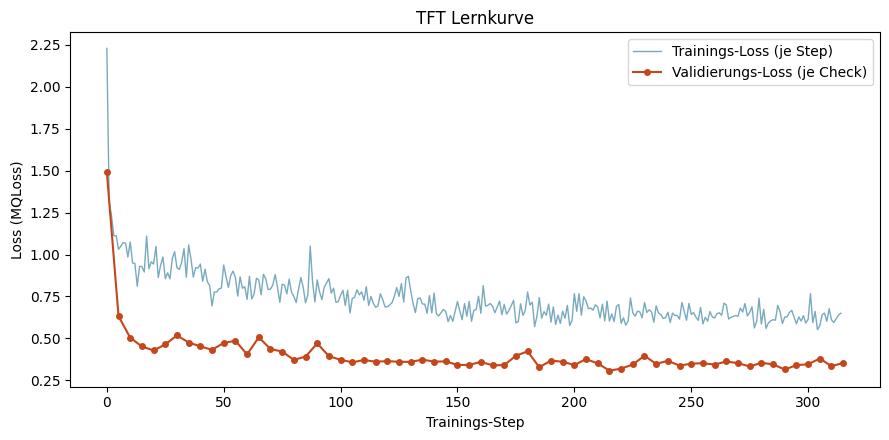

Tatsaechlich trainierte Steps: 314 von MAX_STEPS=1000 -> Early Stopping hat gegriffen!
Letzter Trainings-Loss:      0.6499
Letzter Validierungs-Loss:   0.3534
Hinweis: bester Validierungs-Loss war 0.3080 bei Step 215 -- danach evtl. leichtes Overfitting, oder Early Stopping haette (mit kleinerer patience) frueher greifen koennen.


In [8]:
plotte_lernkurve(model=nf_v2.models[0])


### Hinweis: v2-Modell weiter auswerten

Die Walk-Forward-Horizontauswertung (Abschnitt 4) und `vergleiche_tft()` (Abschnitt 5) sind beide so
gebaut, dass sie ein `nf`-Objekt als Parameter/Variable nehmen -- fuer `nf_v2` entweder die Zelle in
Abschnitt 4 mit `nf` -> `nf_v2` (und eigenem `ergebnis_tft_final_v2.csv`) noch einmal laufen lassen, oder
direkt:

```python
vergleiche_tft(STATIONEN_TEST[0], split_datum='2016-11-01', horizont=72, nf=nf_v2)
```


## 4. Horizont-Vergleich (walk-forward, Schritt = 72h) auf dem zurueckgehaltenen Zeitraum

`cross_validation()` wuerde ein **neues** Modell trainieren (siehe Hinweis oben) -- deshalb hier ein
manueller Walk-Forward mit wiederholtem `nf.predict()` auf dem **einen** oben trainierten/gespeicherten
Modell. Das kann je nach Testzeitraum/Stationsanzahl ein paar Minuten dauern (bei ~6 Monaten Testzeitraum
und 72h-Schritten sind das ~60 `predict()`-Aufrufe).


In [4]:
# nf fuer die Auswertung bereitstellen (Fix fuer: NameError: name 'nf' is not defined) -- OHNE Training
#  - Kernel laeuft noch vom Training? -> nimmt nf_v2 aus dem Speicher.
#  - Kernel neu gestartet?            -> laedt das in Zelle 12 gespeicherte Modell von der Platte.
from pathlib import Path
from neuralforecast import NeuralForecast
MODELL_DIR_LADEN = Path(str(MODELL_DIR) + '_v6')   # = tft_final_multivariat_v8_v6 (Lauf aus Zelle 12)
try:
    nf = nf_v2
    print('OK: Modell aus dem Arbeitsspeicher uebernommen (nf = nf_v2).')
except NameError:
    nf = NeuralForecast.load(path=str(MODELL_DIR_LADEN))
    print(f'OK: Modell von der Platte geladen -> {MODELL_DIR_LADEN}')


Seed set to 1


OK: Modell von der Platte geladen -> ..\models\tft_final_multivariat_v8_v6


In [5]:
fold_start_daten = []
_t = pd.Timestamp(TRAIN_CUTOFF)
while _t + pd.Timedelta(hours=H_TFT) <= DATENENDE:
    fold_start_daten.append(_t)
    _t += pd.Timedelta(hours=H_TFT)
print(f'{len(fold_start_daten)} Walk-Forward-Fenster von {TRAIN_CUTOFF} bis {DATENENDE.date()}')

alle_vorhersagen = []
for i, cutoff in enumerate(fold_start_daten):
    kontext_start = cutoff - pd.Timedelta(hours=INPUT_SIZE + 24)   # kleiner Puffer
    kontext_df = multi[(multi['ds'] >= kontext_start) & (multi['ds'] < cutoff)]
    fenster    = multi[(multi['ds'] >= cutoff) & (multi['ds'] < cutoff + pd.Timedelta(hours=H_TFT))]
    if fenster.empty or fenster['unique_id'].nunique() < len(STATIONEN_TEST):
        continue   # unvollstaendiges letztes Fenster ueberspringen

    futr_df = fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
    pred = nf.predict(df=kontext_df, static_df=stat_df, futr_df=futr_df)
    pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)      # Ruecktransformation aus Log-Raum
    pred['cutoff'] = cutoff

    echte = fenster[['unique_id', 'ds', 'y_original']].rename(columns={'y_original': 'y'})
    vergleich = echte.merge(pred[['unique_id', 'ds', 'cutoff', 'yhat']], on=['unique_id', 'ds'])
    alle_vorhersagen.append(vergleich)

    if (i + 1) % 10 == 0 or i == len(fold_start_daten) - 1:
        print(f'  Fenster {i+1}/{len(fold_start_daten)} ({cutoff.date()}) erledigt')

cv = pd.concat(alle_vorhersagen, ignore_index=True)
cv['lead'] = ((cv['ds'] - cv['cutoff']).dt.total_seconds() // 3600).astype(int)
print(f'\n{len(cv)} Vorhersage-Zeilen gesamt.')


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


60 Walk-Forward-Fenster von 2016-08-30 bis 2017-02-28


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

  Fenster 60/60 (2017-02-23) erledigt

47520 Vorhersage-Zeilen gesamt.


In [6]:
rows = []
for b in HORIZONTE:
    w = cv[cv['lead'] <= b]
    per_station = [{'MAE': mae(g['y'], g['yhat']), 'RMSE': rmse(g['y'], g['yhat']),
                    'MASE': mae(g['y'], g['yhat']) / skalen[st], 'MAPE %': mape(g['y'], g['yhat'])}
                   for st, g in w.groupby('unique_id')]
    m = pd.DataFrame(per_station).mean()
    rows.append({'Modell': 'TFT final (multivariat)', 'Horizont': f'{b} h',
                 'MAE': m['MAE'], 'RMSE': m['RMSE'], 'MASE': m['MASE'], 'MAPE %': m['MAPE %']})

ergebnis_tft_final = pd.DataFrame(rows)[['Modell', 'Horizont', 'MAE', 'RMSE', 'MASE', 'MAPE %']].round(3)
print(ergebnis_tft_final.to_string(index=False))

ERGEBNIS_CSV.parent.mkdir(parents=True, exist_ok=True)
ergebnis_tft_final.to_csv(ERGEBNIS_CSV, index=False)
print(f'\ngespeichert -> {ERGEBNIS_CSV}')


                 Modell Horizont    MAE   RMSE  MASE  MAPE %
TFT final (multivariat)      8 h 26.037 42.413 0.460  50.653
TFT final (multivariat)     24 h 32.434 56.460 0.574  54.814
TFT final (multivariat)     48 h 37.470 67.318 0.663  61.298
TFT final (multivariat)     72 h 39.666 69.213 0.702  71.220

gespeichert -> ..\data\ergebnis_tft_final_v8.csv


## 5. Vergleichsplot: echte Werte vs. TFT-Prognose fuer ein beliebiges Split-Datum

`vergleiche_tft(station, split_datum, horizont=H_TFT)` -- nutzt das oben trainierte (oder ein per
`NeuralForecast.load()` geladenes) Modell, plottet echte vs. prognostizierte Werte und gibt den MAE
zurueck/aus. Funktioniert fuer jedes `split_datum` **innerhalb** des in `multi` verfuegbaren Zeitraums
(Kontext davor muss mindestens `INPUT_SIZE` Stunden umfassen).


In [10]:
def vergleiche_tft(station, split_datum, horizont=H_TFT, nf=nf, multi=multi, stat_df=stat_df,
                   input_size=INPUT_SIZE, farbe_echt='#3A4148', farbe_modell='#7B2CBF'):
    '''Plottet echte PM2.5-Werte vs. TFT-Prognose fuer `station` ab `split_datum` (`horizont` Stunden)
    und gibt (vergleich_df, mae_wert) zurueck. Gibt den MAE zusaetzlich aus.'''
    split_datum = pd.Timestamp(split_datum)
    kontext_start = split_datum - pd.Timedelta(hours=input_size + 24)

    kontext_df = multi[(multi['unique_id'] == station) &
                       (multi['ds'] >= kontext_start) & (multi['ds'] < split_datum)]
    fenster = multi[(multi['unique_id'] == station) &
                    (multi['ds'] >= split_datum) & (multi['ds'] < split_datum + pd.Timedelta(hours=horizont))]

    if kontext_df.empty:
        raise ValueError(f'Kein Kontext vor {split_datum.date()} fuer Station {station} verfuegbar.')
    if fenster.empty:
        raise ValueError(f'Kein Testfenster ab {split_datum.date()} fuer Station {station} verfuegbar '
                         f'(Datenende: {multi["ds"].max()}).')

    stat_zeile = stat_df[stat_df['unique_id'] == station]
    futr_df = fenster[['unique_id', 'ds'] + REGRESSOREN_ZUKUNFT]
    pred = nf.predict(df=kontext_df, static_df=stat_zeile, futr_df=futr_df)
    pred['yhat'] = np.expm1(pred['TFT-median']).clip(lower=0)
    if 'TFT-lo-80.0' in pred.columns:
        pred['yhat_lo'] = np.expm1(pred['TFT-lo-80.0']).clip(lower=0)
        pred['yhat_hi'] = np.expm1(pred['TFT-hi-80.0']).clip(lower=0)

    echte = fenster[['ds', 'y_original']].rename(columns={'y_original': 'y'})
    vergleich = echte.merge(pred, on='ds')
    mae_wert = mae(vergleich['y'], vergleich['yhat'])

    plt.figure(figsize=(11, 4))
    if 'yhat_lo' in vergleich.columns:
        plt.fill_between(vergleich['ds'], vergleich['yhat_lo'], vergleich['yhat_hi'],
                         color=farbe_modell, alpha=0.15, label='80%-Prognoseintervall')
    plt.plot(vergleich['ds'], vergleich['y'], color=farbe_echt, lw=1.6, label='echte Werte')
    plt.plot(vergleich['ds'], vergleich['yhat'], color=farbe_modell, lw=1.6, label='TFT-Prognose')
    plt.ylabel('PM2.5 (\u00b5g/m\u00b3)')
    plt.title(f'{station} \u2014 ab {split_datum.date()} ({horizont}h) \u2014 MAE = {mae_wert:.2f}')
    plt.legend(loc='best'); plt.tight_layout(); plt.show()

    print(f'MAE ({station}, ab {split_datum.date()}, {horizont}h): {mae_wert:.2f} \u00b5g/m\u00b3')
    return vergleich, mae_wert


### Beispielaufrufe

Split-Datum und Station frei anpassen -- funktioniert fuer jede Station in `STATIONEN_TEST` und jedes
Datum, fuer das genug Kontext (`INPUT_SIZE` Stunden davor) und ein volles Testfenster (danach) vorliegen.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

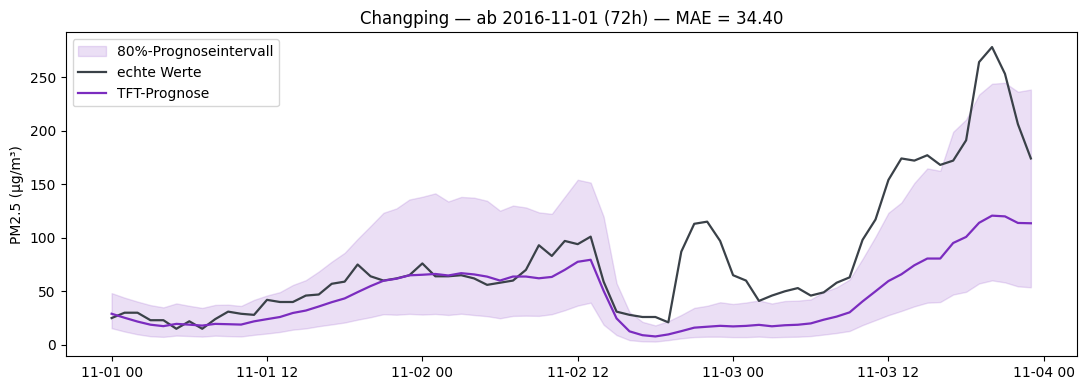

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Changping, ab 2016-11-01, 72h): 34.40 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

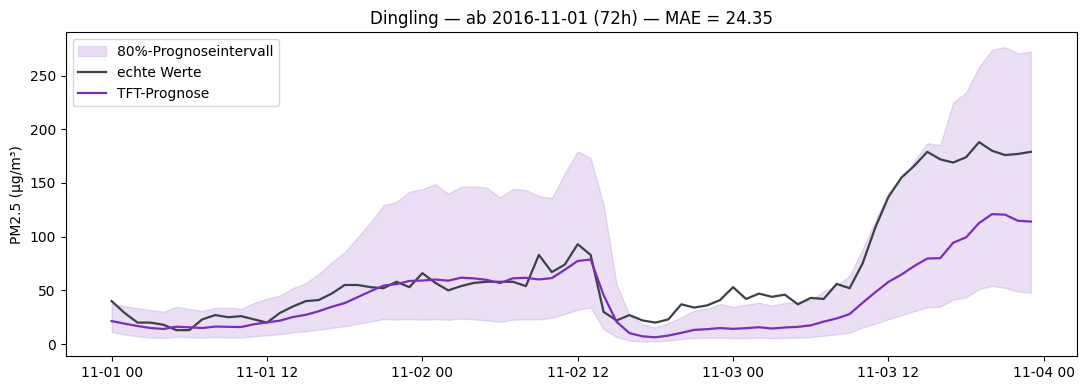

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dingling, ab 2016-11-01, 72h): 24.35 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

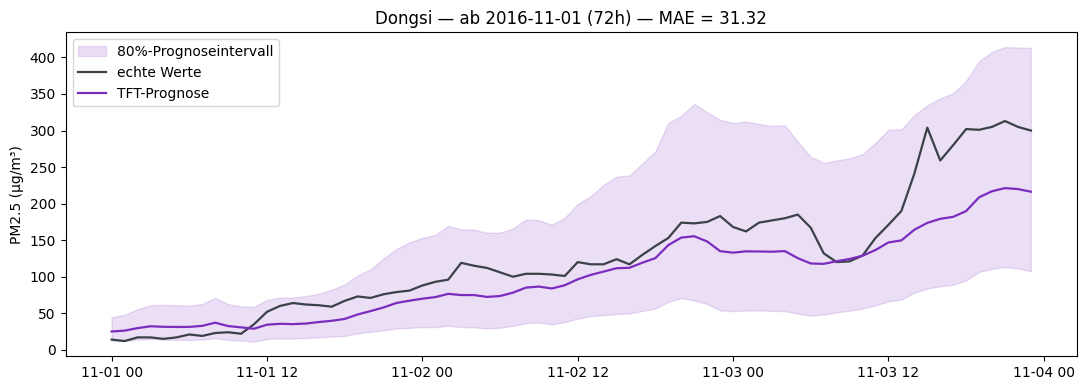

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Dongsi, ab 2016-11-01, 72h): 31.32 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

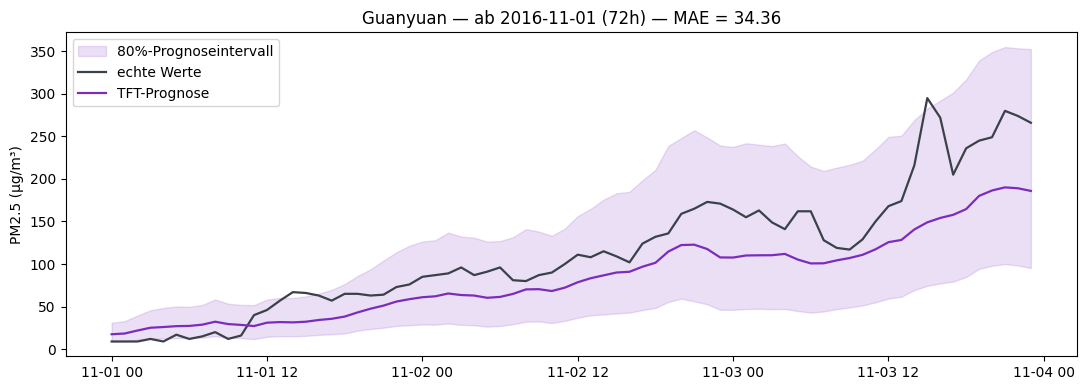

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Guanyuan, ab 2016-11-01, 72h): 34.36 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

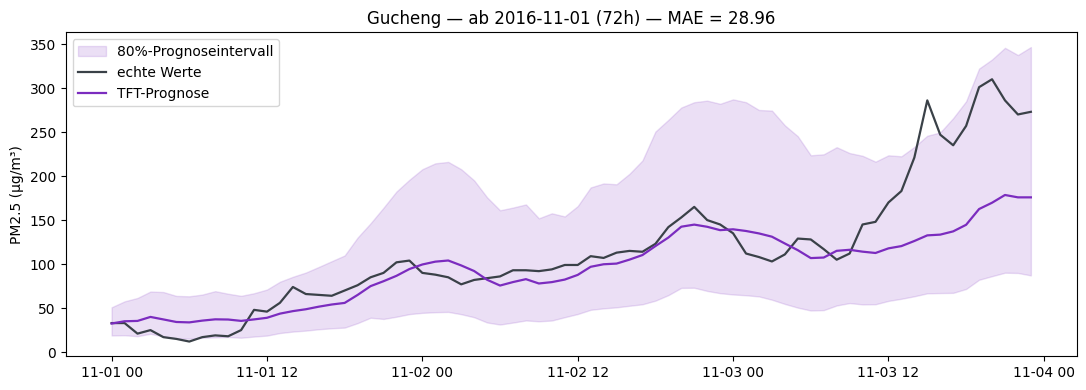

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Gucheng, ab 2016-11-01, 72h): 28.96 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

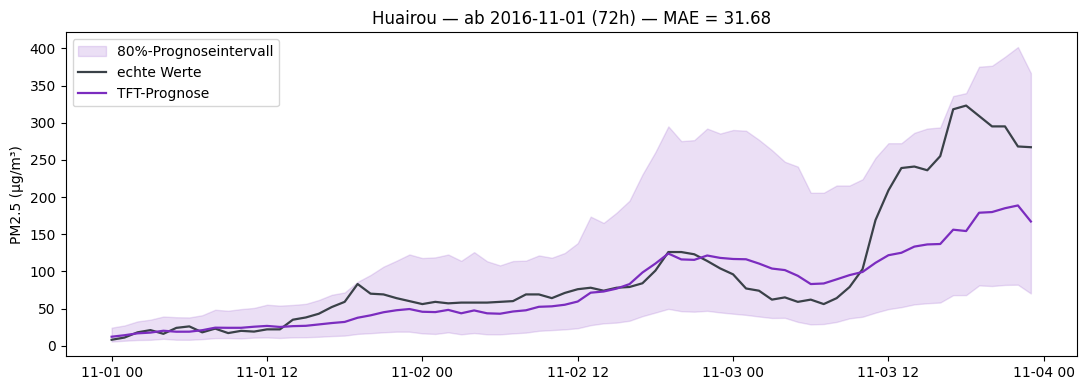

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Huairou, ab 2016-11-01, 72h): 31.68 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

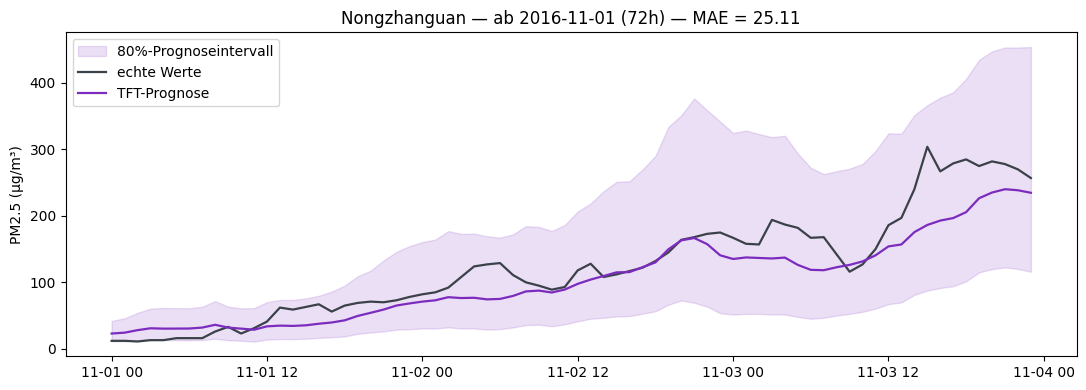

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Nongzhanguan, ab 2016-11-01, 72h): 25.11 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

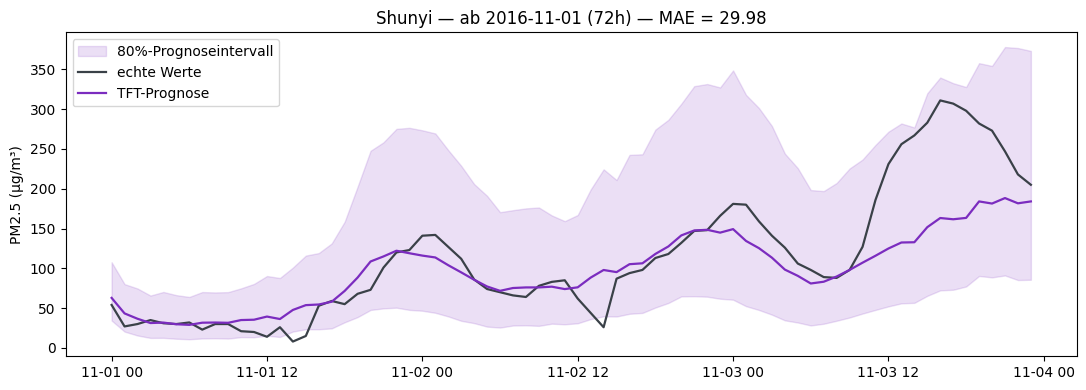

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Shunyi, ab 2016-11-01, 72h): 29.98 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

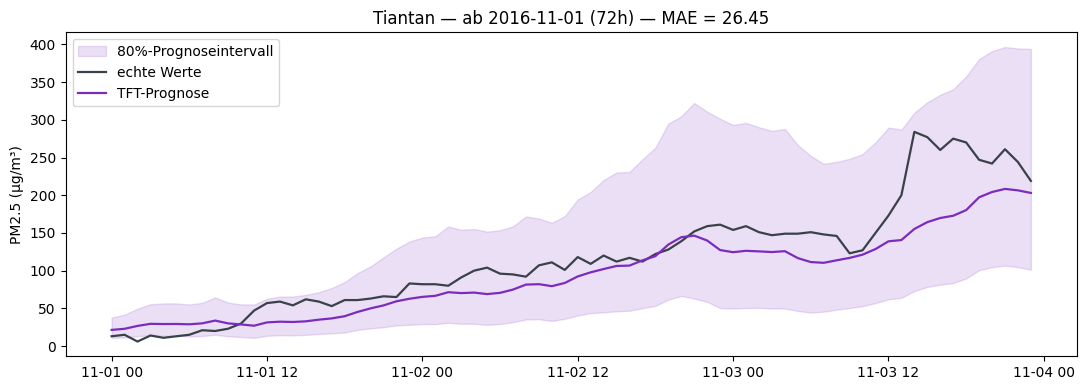

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Tiantan, ab 2016-11-01, 72h): 26.45 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

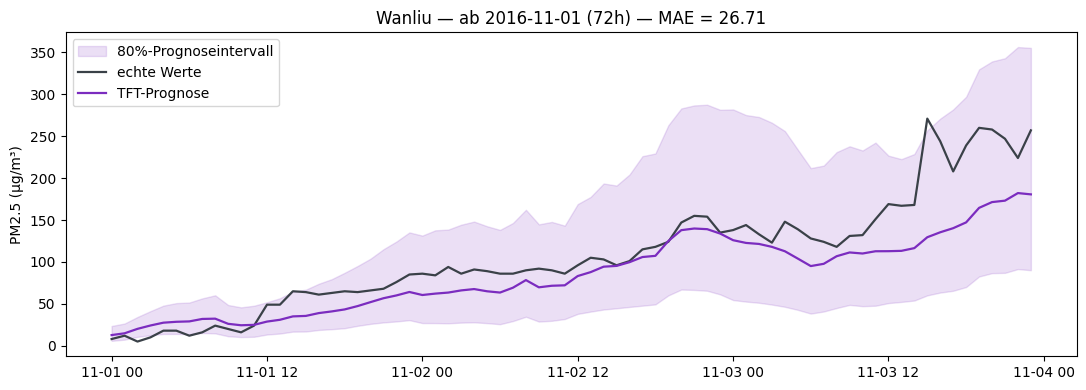

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE (Wanliu, ab 2016-11-01, 72h): 26.71 µg/m³


Predicting: |          | 0/? [00:00<?, ?it/s]

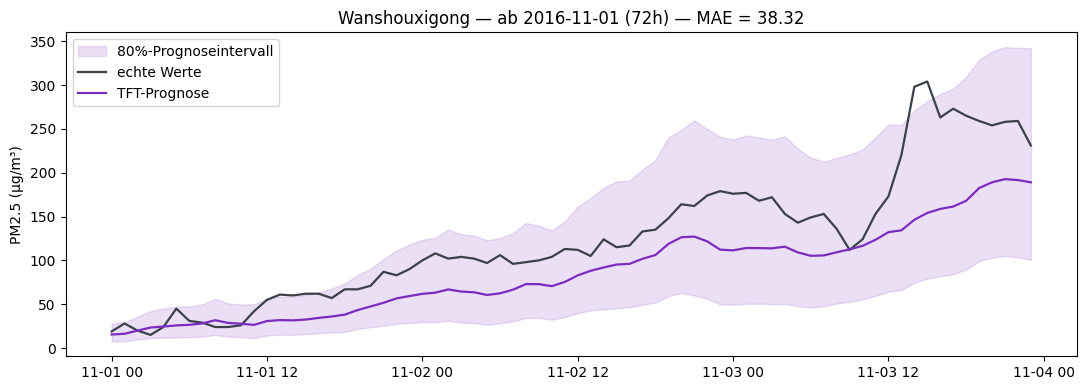

MAE (Wanshouxigong, ab 2016-11-01, 72h): 38.32 µg/m³


In [11]:
for station in STATIONEN_TEST:
    _ = vergleiche_tft(station, split_datum='2016-11-01', horizont=72)
